# Demo Script - Real vs AI-Generated Faces: ResNet vs Vision Transformer

In this notebook, we present the inference results and interpretability analysis of our models. We evaluate both a CNN (ResNet) and a Vision Transformer (ViT) on the real vs fake face classification task, and analyze how each model makes its decisions.

The notebook is structured as follows:

1. CNN (ResNet)
   - 1.1. Load Model
   - 1.2. Evaluate Model Performance (accuracy, loss, confusion matrix, and ROC curves)
   - 1.3. Grad-CAM Results
   - 1.4. Average Grad-CAM and Overlay
        - 1.4.1. Real vs GAN
        - 1.4.2. Real vs Diffusion
        - 1.4.3. Real vs Face Swaps
2. Vision Transformer (ViT)
   - 2.1. Load Model
   - 2.2. Evaluate Model Performance (accuracy, loss, confusion matrix, and ROC curves)
   - 2.3. Grad-CAM Results
   - 2.4. Average Grad-CAM and Overlay
   - 2.5. Attention Rollout Analysis
        - 2.5.1. Real vs GAN
        - 2.5.2. Real vs Diffusion
        - 2.5.3. Real vs Face Swaps


**Please refer to our individual notebooks (ResNet.ipynb and ViT.ipynb) as  well as our helper functions in the resnet_helpers/ and vit_helpers/ folders for for more details about our implementations.**

- GitHub: https://github.com/wu-hanson/deepface_insight.git
- ViT Model (Google Drive): https://drive.google.com/file/d/1FhS-U81hGNye6CCneMZS3oZY5i0NX3Fs/view?usp=share_link

**Make sure to include vit_model.pth in the same directory if you wish to run this notebook**

In [ ]:
import os
import random
from pathlib import Path
import cv2

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset

from torchvision import transforms
from torchvision.transforms import Normalize
from torchvision import datasets, transforms
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc

from resnet_helpers.resnet_model import *
from resnet_helpers.resnet_gradcam import *

from vit_helpers.vit_data_utils import *
from vit_helpers.vit_model import *
from vit_helpers.vit_gradcam import *
from vit_helpers.vit_attention_rollout import *

from data_utils import *

device = torch.device("cuda")
print("Using device:", device)

Using device: cuda


In [ ]:
# Uncomment to download and structure the dataset

#download_and_create_data_folder()
#clean_source_folders()

In [2]:
loss = nn.CrossEntropyLoss()

data_dir = Path("data/dataset")  # dataset/train, dataset/test, dataset/validate
test_dir  = data_dir / "test"

resnet_model_path = "resnet_model.pth"
resnet_model = load_resnet_model(resnet_model_path, device)


# 1. CNN (ResNet)

## 1.2 Evaluate Model Performance

In [3]:
# ============================================================================
# Evaluate Model on Test Set
# ============================================================================
print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)


eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


test_dataset = datasets.ImageFolder(test_dir, transform=eval_transform)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)
resnet_model.eval()

test_running_loss = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        outputs = resnet_model(inputs)
        batch_loss = loss(outputs, labels)

        test_running_loss += batch_loss.item() * inputs.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

test_loss = test_running_loss / len(test_loader.dataset)
test_acc = accuracy_score(all_labels, all_preds)
test_precision = precision_score(all_labels, all_preds)
test_recall = recall_score(all_labels, all_preds)
test_f1 = f1_score(all_labels, all_preds)

 # Print metrics
print("\nPerformance Metrics:")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Precision: {test_precision:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1-score: {test_f1:.4f}")


TEST SET EVALUATION

Performance Metrics:
Test Loss: 0.0544
Test Accuracy: 0.9864
Test Precision: 0.9915
Test Recall: 0.9761
Test F1-score: 0.9837


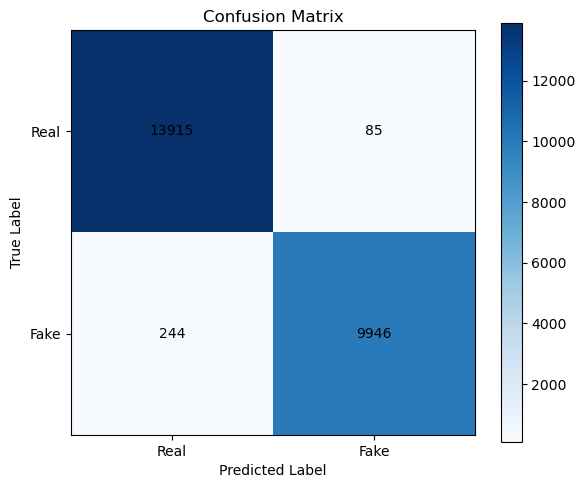

In [4]:
# Confusion Matrix

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest", cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Real", "Fake"])
plt.yticks(tick_marks, ["Real", "Fake"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.savefig("resnet_model_outputs/confusion_matrix.png", dpi=300)
plt.show()

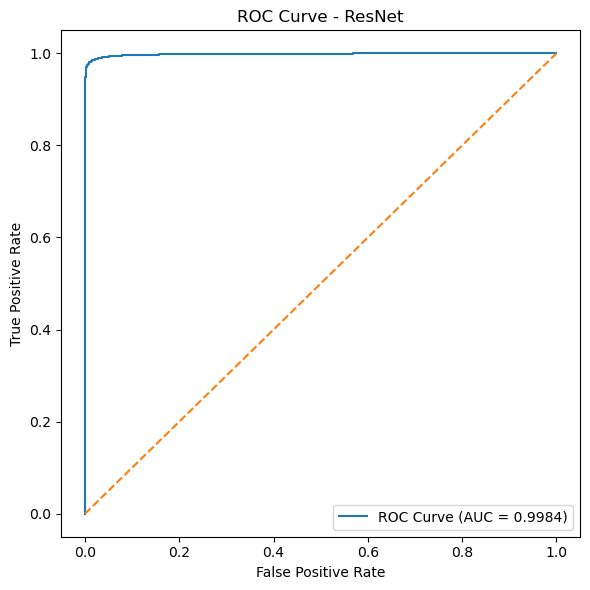

In [5]:
# ROC

all_probs = []
all_labels = []

resnet_model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        outputs = resnet_model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of "fake"

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())


fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ResNet")
plt.legend()

plt.tight_layout()
plt.savefig("resnet_model_outputs/roc_curve.png", dpi=300)
plt.show()


## 1.3 Grad-CAM Results

In [6]:
# ============================================================================
# Load Image Paths from Source Directories
# ============================================================================

base_source = os.path.expanduser("~/cs7150_project/data/source")

real_dir = os.path.join(base_source, "real")
gan_dir = os.path.join(base_source, "fake", "GAN")
diff_dir = os.path.join(base_source, "fake", "Diffusion")
faceswap_dir = os.path.join(base_source, "fake", "FaceSwap")

real_paths = [
    os.path.join(real_dir, f)
    for f in os.listdir(real_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

gan_paths = [
    os.path.join(gan_dir, f)
    for f in os.listdir(gan_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

diff_paths = [
    os.path.join(diff_dir, f)
    for f in os.listdir(diff_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

faceswap_paths = [
    os.path.join(faceswap_dir, f)
    for f in os.listdir(faceswap_dir)
    if f.lower().endswith((".png", ".jpg", ".jpeg", ".webp"))
]

print(f"\nImage counts by source:")
print("Real:", len(real_paths))
print("GAN:", len(gan_paths))
print("Diffusion:", len(diff_paths))
print("FaceSwap:", len(faceswap_paths))


Image counts by source:
Real: 70000
GAN: 40499
Diffusion: 1031
FaceSwap: 9429


In [7]:
# ============================================================================
# Initialize Grad-CAM and Utilities
# ============================================================================
print("\n" + "="*70)
print("INITIALIZING GRAD-CAM")
print("="*70)

# Initialize Grad-CAM
grad_cam = ResNetGradCAM(resnet_model, target_layer=resnet_model.layer4[-1].conv2)

label_map = {0: "Real", 1: "Fake"}

# Inverse normalization for visualization (undo ImageNet normalization)
inv_normalize = Normalize(
    mean=[-0.485 / 0.229, -0.456 / 0.224, -0.406 / 0.225],
    std=[1 / 0.229, 1 / 0.224, 1 / 0.225],
)

print("✓ Grad-CAM initialized")
print("✓ Visualization utilities ready")


INITIALIZING GRAD-CAM
✓ Grad-CAM initialized
✓ Visualization utilities ready



GENERATING 1x4 GRAD-CAM VISUALIZATION


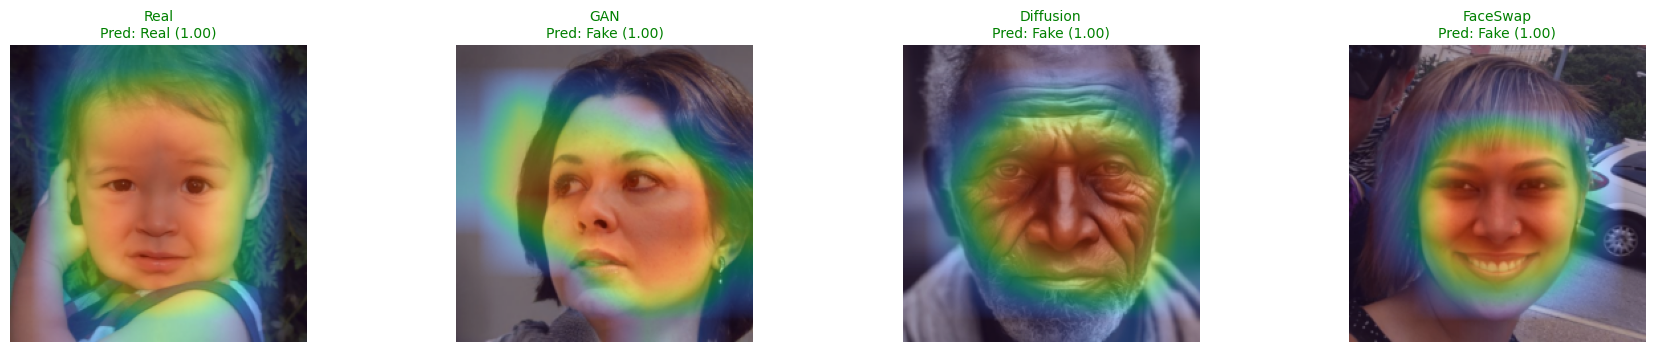

In [8]:
# ============================================================================
# Generate 1x4 Grad-CAM Visualization (Real, GAN, Diffusion, FaceSwap)
# ============================================================================

print("\n" + "="*70)
print("GENERATING 1x4 GRAD-CAM VISUALIZATION")
print("="*70)

categories = {
    "Real": real_paths,
    "GAN": gan_paths,
    "Diffusion": diff_paths,
    "FaceSwap": faceswap_paths
}

num_rows = 1

grad_cam = ResNetGradCAM(resnet_model, target_layer=resnet_model.layer4[-1].conv2)

for row_idx in range(num_rows):
    fig, axes = plt.subplots(1, 4, figsize=(18, 4))

    for col_idx, (cat_name, img_list) in enumerate(categories.items()):
        img_path = random.sample(img_list, 1)[0]

        img = Image.open(img_path).convert("RGB")
        img_tensor = eval_transform(img).unsqueeze(0).to(device)

        outputs = resnet_model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_class = outputs.argmax(dim=1).item()
        pred_conf = probs[0, pred_class].item()

        cam = grad_cam.generate_cam(img_tensor, target_class=pred_class)

        img_vis = inv_normalize(img_tensor[0].cpu()).numpy().transpose(1, 2, 0)
        img_vis = np.clip(img_vis * 255, 0, 255).astype(np.uint8)

        overlay = GradCAMVisualization.create_heatmap(img_vis, cam)

        ax = axes[col_idx]
        ax.imshow(overlay)
        ax.axis("off")

        pred_label = label_map[pred_class]
        correct = ((cat_name == "Real" and pred_label == "Real") or
                   (cat_name != "Real" and pred_label == "Fake"))

        title_color = "green" if correct else "red"
        ax.set_title(
            f"{cat_name}\nPred: {pred_label} ({pred_conf:.2f})",
            color=title_color,
            fontsize=10
        )

    plt.tight_layout(rect=[0, 0.05, 1, 0.95])

    save_path = f"resnet_gradcam_outputs/resnet_gradcam_row_{row_idx + 1}.png"
    plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()
    plt.close()

grad_cam.remove_hooks()

## 1.4 Average Grad-CAM and Overlay

In [9]:
# ============================================================================
# Take Sample of 1000 and get real images Grad-CAM
# ============================================================================

real_sample = random.sample(real_paths, min(1000, len(real_paths)))
gan_sample = random.sample(gan_paths, min(1000, len(gan_paths)))
diff_sample = random.sample(diff_paths, min(1000, len(diff_paths)))
faceswap_sample = random.sample(faceswap_paths, min(1000, len(faceswap_paths)))

real_cams = []
real_imgs = []

for img_path in real_sample:
    img = Image.open(img_path).convert("RGB")
    img_tensor = eval_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = resnet_model(img_tensor)
        pred_class = outputs.argmax(dim=1).item()

    cam = grad_cam.generate_cam(img_tensor, target_class=pred_class)
    real_cams.append(cam)

    img_vis = inv_normalize(img_tensor[0].cpu()).numpy().transpose(1, 2, 0)
    img_vis = np.clip(img_vis, 0, 1)
    real_imgs.append(img_vis)

# Compute average attention map for real faces
if real_cams:
    avg_real_cam = np.mean(real_cams, axis=0)
    avg_real_img = np.mean(real_imgs, axis=0)
    real_overlay = GradCAMVisualization.create_heatmap(
        (avg_real_img * 255).astype(np.uint8),
        avg_real_cam
    )

    
    stats = compute_and_print_attention_statistics(real_cams, "Real Faces")
    print("✓ Real image attention maps computed and stored\n")
else:
    print("✗ Failed to compute real image attention maps")
    real_cams = []
    avg_real_cam = None
    avg_real_img = None
    real_overlay = None


Real Faces Attention Statistics:
  Mean: 0.1937 | Std: 0.2877
  Min:  0.0000 | Max: 1.0000
✓ Real image attention maps computed and stored



### 1.4.1 Real vs GAM


ANALYZE REAL VS GAN

Processing GAN with layer1...
layer1 | Real mean: 0.0812, std: 0.0266
layer1 | GAN mean: 0.1262, std: 0.0433
Mean Difference:0.0450


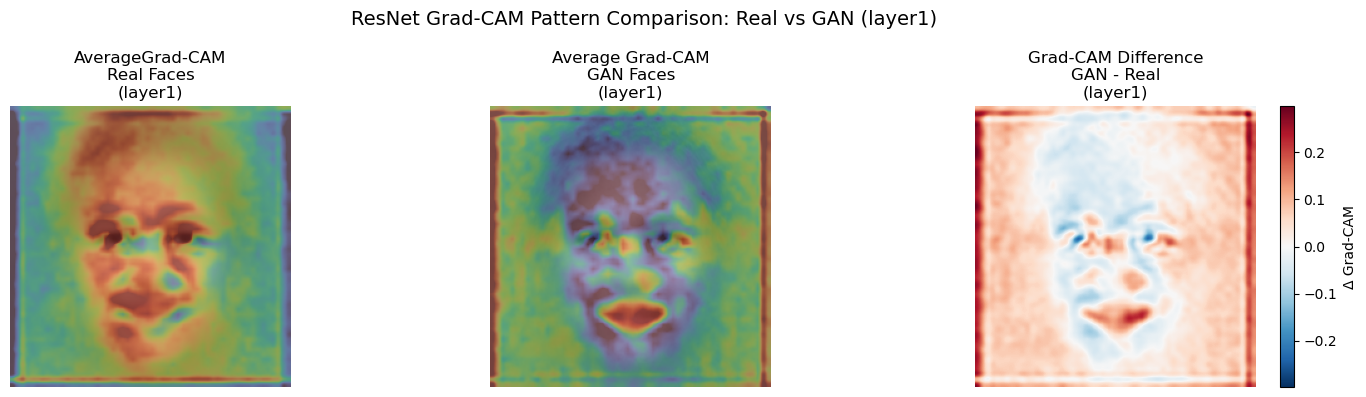


Processing GAN with layer2...
layer2 | Real mean: 0.1443, std: 0.0494
layer2 | GAN mean: 0.0677, std: 0.0538
Mean Difference:-0.0766


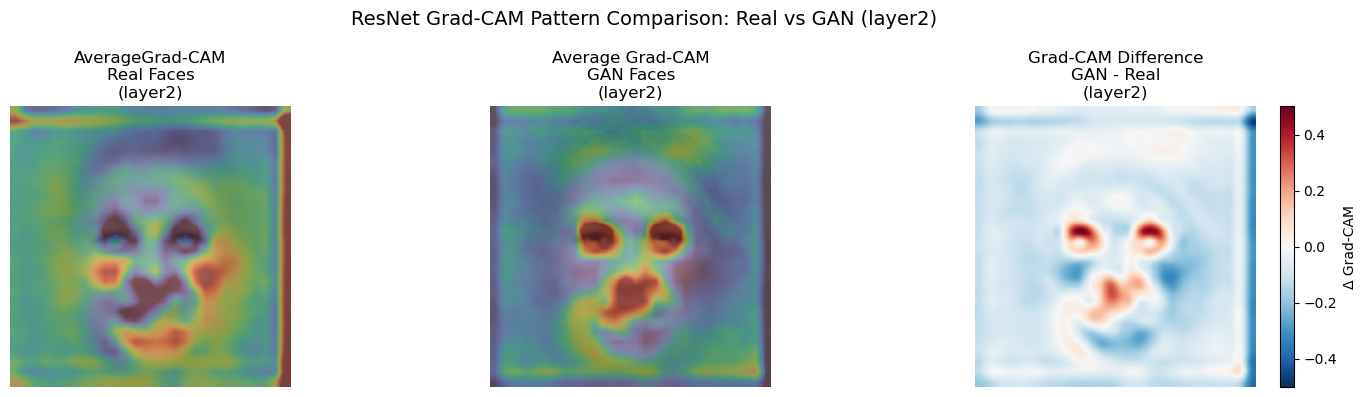


Processing GAN with layer3...
layer3 | Real mean: 0.2433, std: 0.0825
layer3 | GAN mean: 0.1230, std: 0.0826
Mean Difference:-0.1202


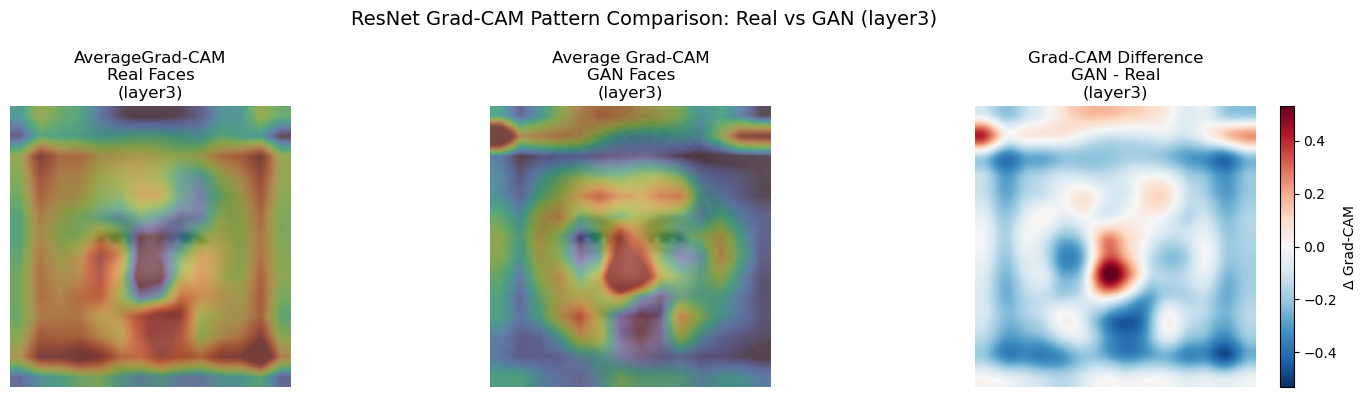


Processing GAN with layer4...
layer4 | Real mean: 0.3575, std: 0.2404
layer4 | GAN mean: 0.3106, std: 0.2324
Mean Difference:-0.0469


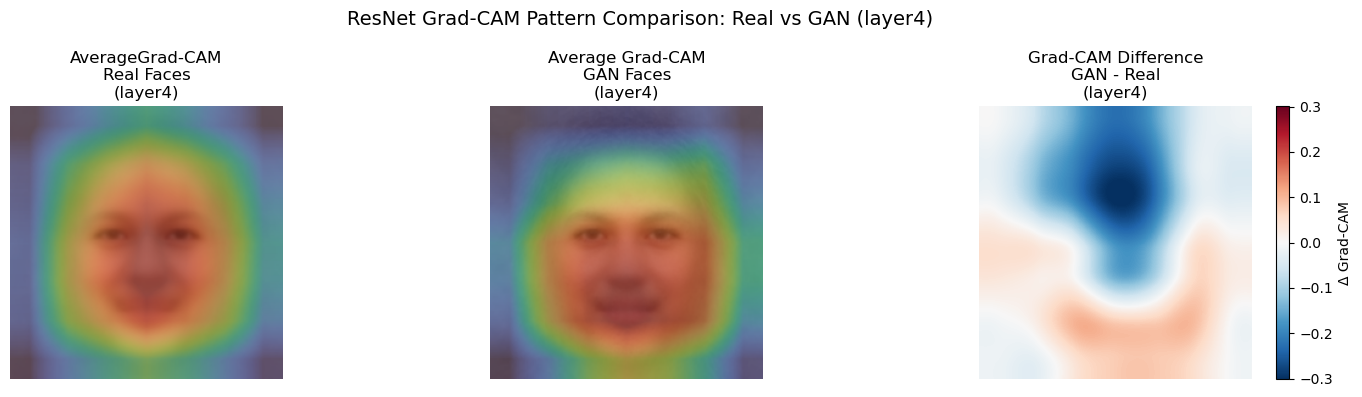

In [10]:
# ============================================================================
# Analyze Real vs GAN
# ============================================================================

print("\n" + "="*70)
print("ANALYZE REAL VS GAN")
print("="*70)


compare_gradcam_patterns(
    real_sample=real_sample,
    fake_sample=gan_sample,
    fake_name="GAN",
    model=resnet_model,
    eval_transform=eval_transform,
    inv_normalize=inv_normalize,
    device=device
)

### 1.4.2 Real vs Diffusion


ANALYZE REAL VS GAN

Processing Diffusion with layer1...
layer1 | Real mean: 0.0812, std: 0.0266
layer1 | Diffusion mean: 0.1182, std: 0.0202
Mean Difference:0.0370


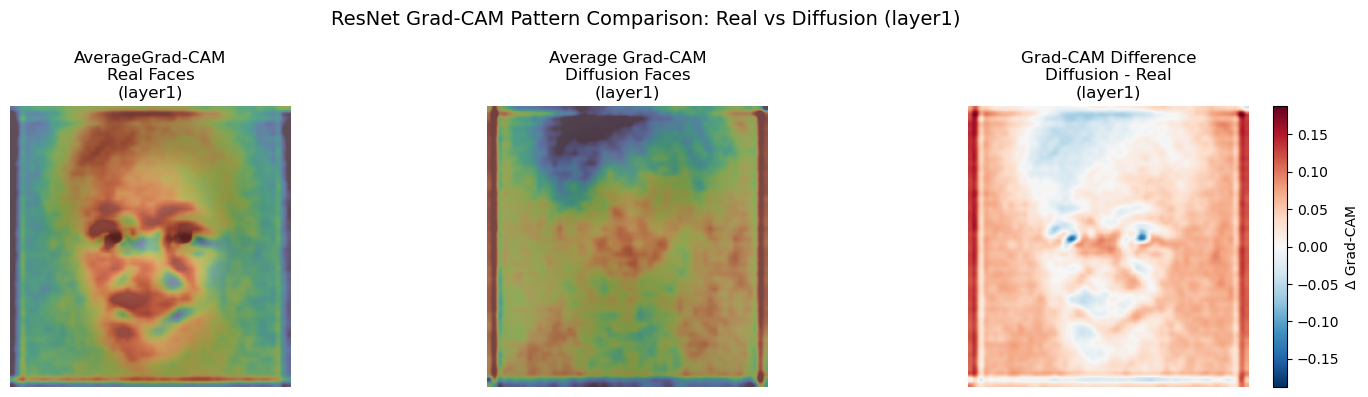


Processing Diffusion with layer2...
layer2 | Real mean: 0.1443, std: 0.0494
layer2 | Diffusion mean: 0.0879, std: 0.0268
Mean Difference:-0.0564


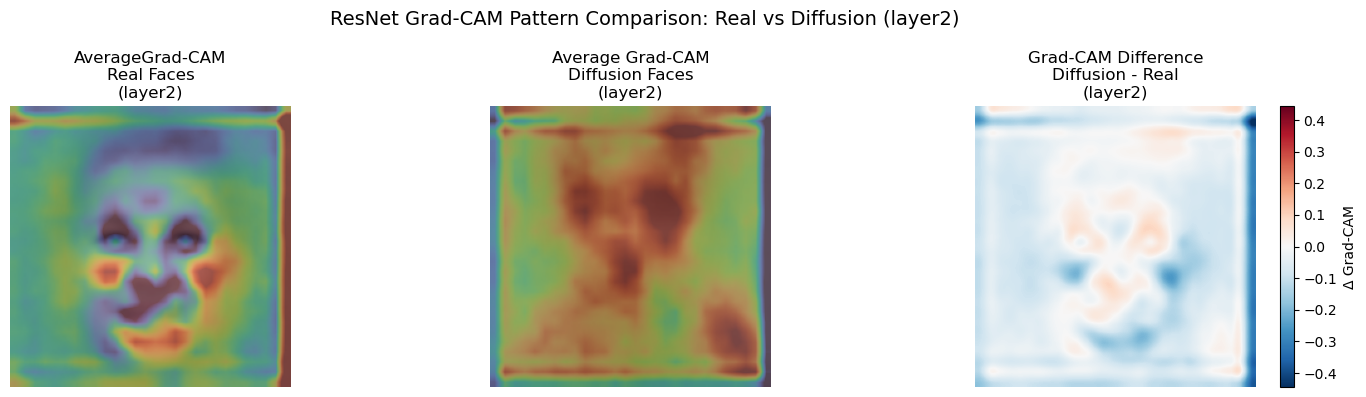


Processing Diffusion with layer3...
layer3 | Real mean: 0.2433, std: 0.0825
layer3 | Diffusion mean: 0.0553, std: 0.0368
Mean Difference:-0.1880


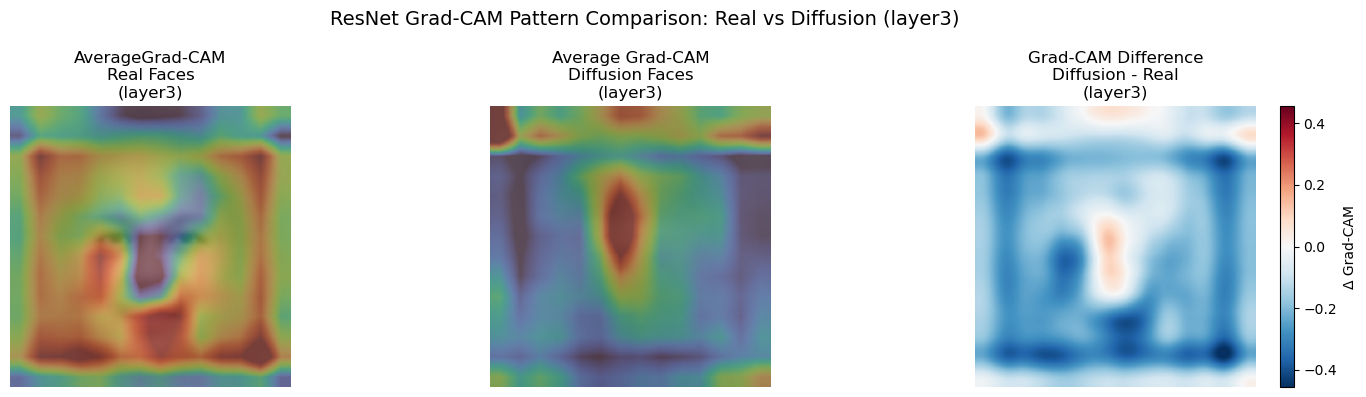


Processing Diffusion with layer4...
layer4 | Real mean: 0.3575, std: 0.2404
layer4 | Diffusion mean: 0.2518, std: 0.2585
Mean Difference:-0.1057


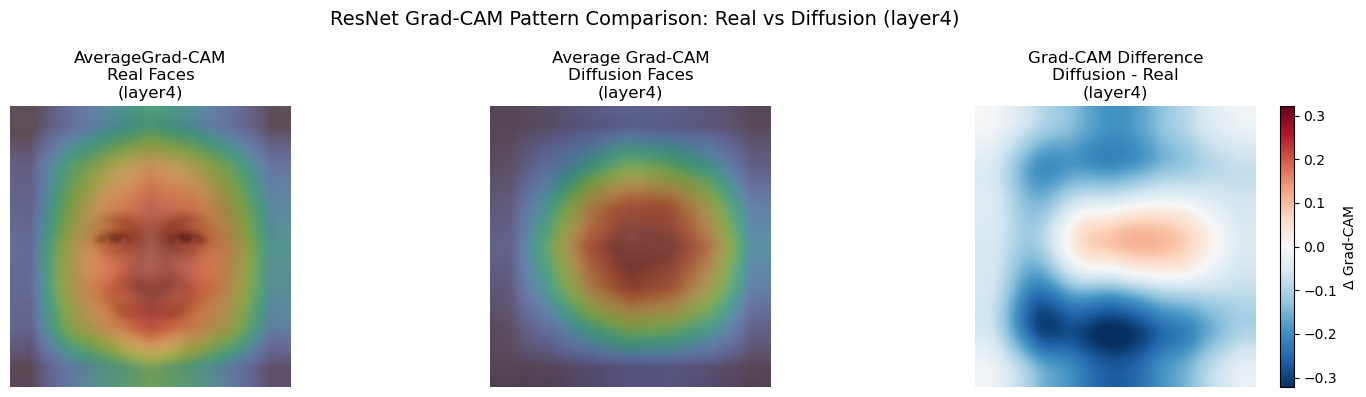

In [11]:
# ============================================================================
# Analyze Real vs Diffusion
# ============================================================================

print("\n" + "="*70)
print("ANALYZE REAL VS GAN")
print("="*70)

compare_gradcam_patterns(
    real_sample=real_sample,
    fake_sample=diff_sample,
    fake_name="Diffusion",
    model=resnet_model,
    eval_transform=eval_transform,
    inv_normalize=inv_normalize,
    device=device
)

### 1.4.3 Real vs Face Swaps


ANALYZE REAL VS FACESWAP

Processing FaceSwap with layer1...
layer1 | Real mean: 0.0812, std: 0.0266
layer1 | FaceSwap mean: 0.0818, std: 0.0369
Mean Difference:0.0007


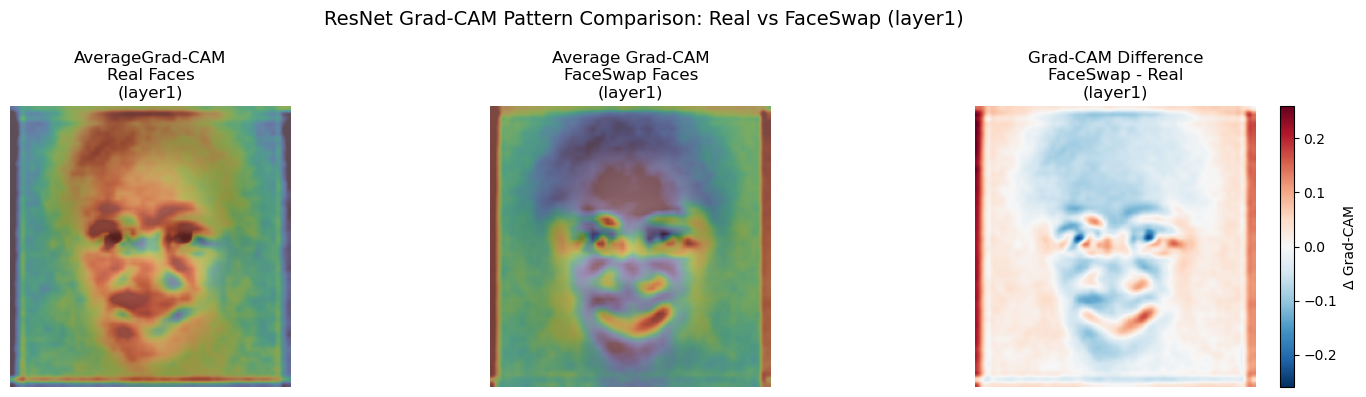


Processing FaceSwap with layer2...
layer2 | Real mean: 0.1443, std: 0.0494
layer2 | FaceSwap mean: 0.1164, std: 0.0501
Mean Difference:-0.0279


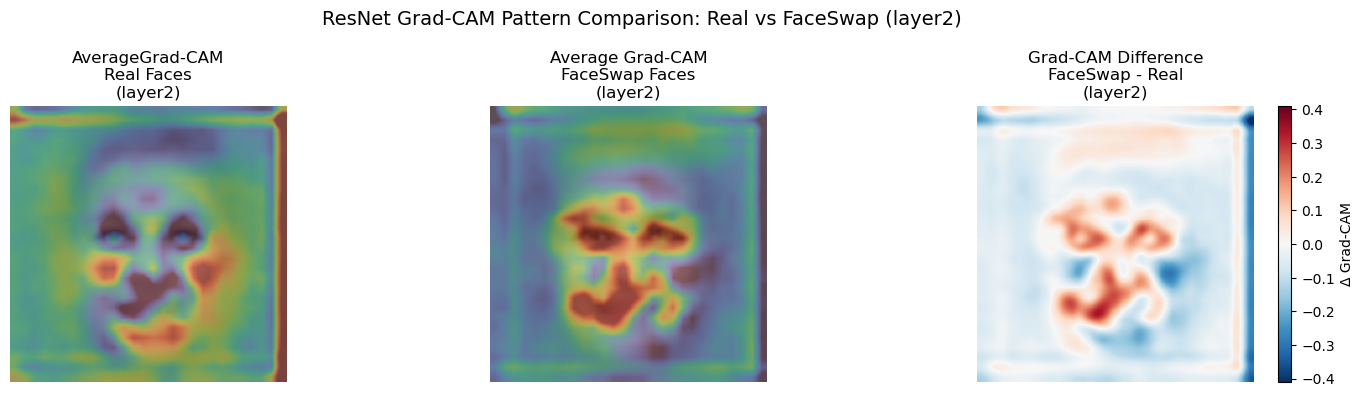


Processing FaceSwap with layer3...
layer3 | Real mean: 0.2433, std: 0.0825
layer3 | FaceSwap mean: 0.1028, std: 0.1169
Mean Difference:-0.1404


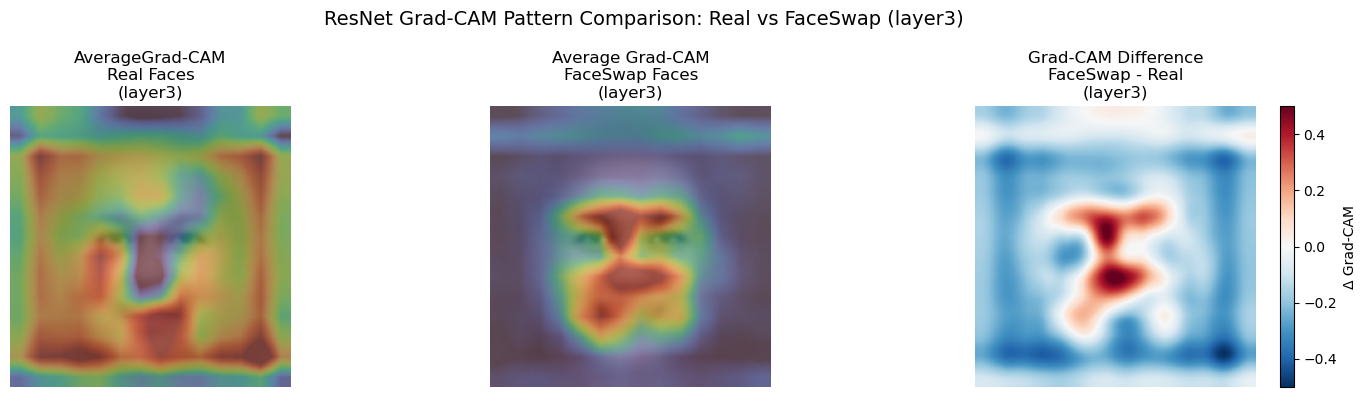


Processing FaceSwap with layer4...
layer4 | Real mean: 0.3575, std: 0.2404
layer4 | FaceSwap mean: 0.2093, std: 0.2788
Mean Difference:-0.1482


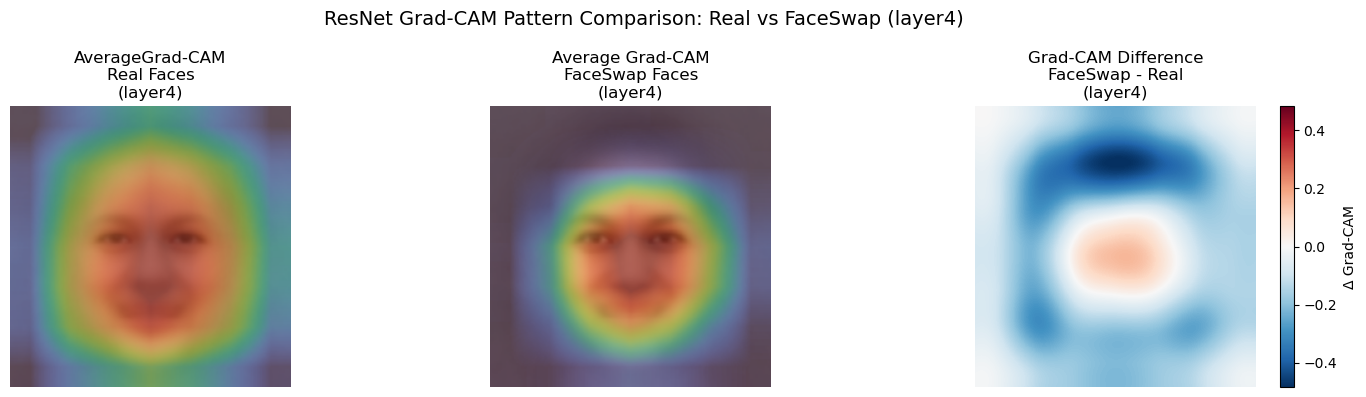

In [12]:
# ============================================================================
# Analyze Real vs Face Swaps
# ============================================================================

print("\n" + "="*70)
print("ANALYZE REAL VS FACESWAP")
print("="*70)

compare_gradcam_patterns(
    real_sample=real_sample,
    fake_sample=faceswap_sample,
    fake_name="FaceSwap",
    model=resnet_model,
    eval_transform=eval_transform,
    inv_normalize=inv_normalize,
    device=device
)

# 2. Vision Transformer (ViT)

## 2.1 Load Model

In [13]:

vit_model = ViTFaceDetector(
    model_name='vit_base_patch16_224',
    pretrained=True
)
# Initialize trainer
trainer = ViTTrainer(
    model=vit_model,
    device=device,
    learning_rate=1e-4,
    weight_decay=1e-5
)


trainer.load_checkpoint("vit_model.pth")



INFO:vit_helpers.vit_model:Initialized vit_base_patch16_224 with pretrained=True
INFO:vit_helpers.vit_model:Trainer initialized on device: cuda
INFO:vit_helpers.vit_model:Loaded checkpoint from vit_model.pth


## 2.2 Evaluate Model Performance

In [14]:
# ============================================================================
# Evaluate Model on Test Set
# ============================================================================
print("\n" + "="*70)
print("TEST SET EVALUATION")
print("="*70)

# Evaluate on test set
print("\nEvaluating on test set...")
test_results = trainer.evaluate(test_loader)

# Compute metrics
y_true = test_results['ground_truth']
y_pred = test_results['predictions']

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# Print metrics
print("\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy*100:>6.2f}%")
print(f"  Precision: {precision*100:>6.2f}%")
print(f"  Recall:    {recall*100:>6.2f}%")
print(f"  F1-Score:  {f1*100:>6.2f}%")




TEST SET EVALUATION

Evaluating on test set...


Testing: 100%|██████████| 756/756 [02:45<00:00,  4.56it/s]


Performance Metrics:
  Accuracy:   97.98%
  Precision:  98.01%
  Recall:     97.98%
  F1-Score:   97.98%


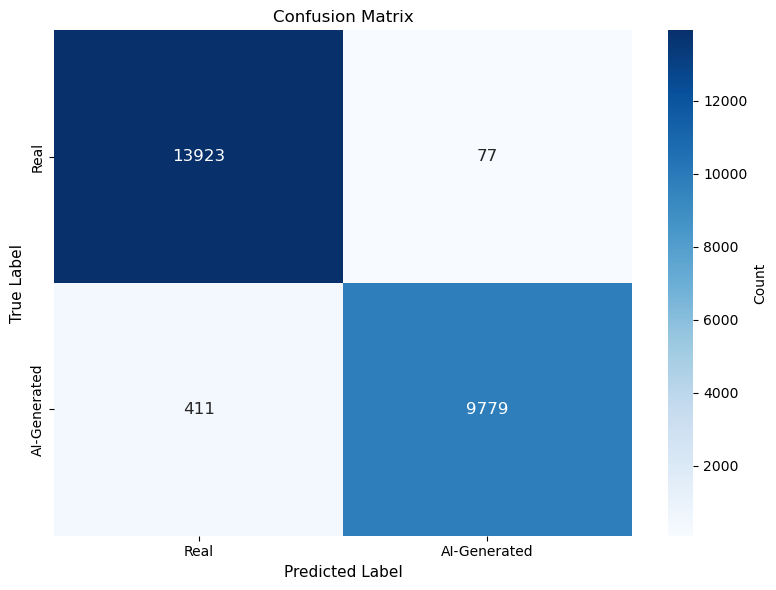

In [15]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Real', 'AI-Generated'],
            yticklabels=['Real', 'AI-Generated'],
            cbar_kws={'label': 'Count'},
            annot_kws={'fontsize': 12})
plt.xlabel('Predicted Label', fontsize=11)
plt.ylabel('True Label', fontsize=11)
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

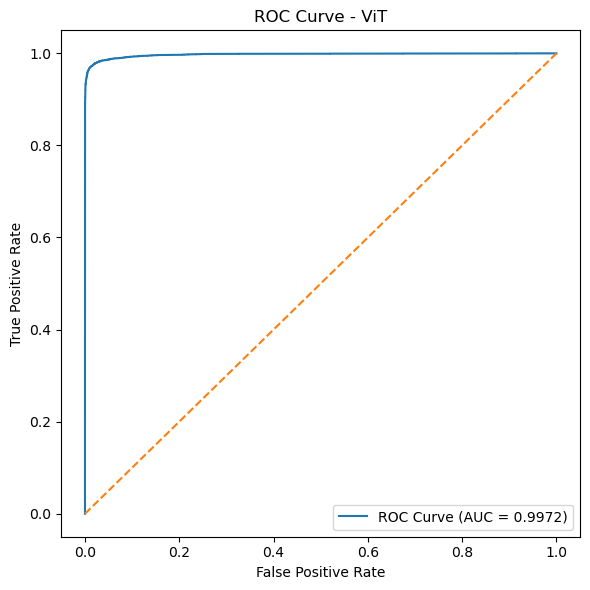

In [16]:
# ROC

all_probs = []
all_labels = []

vit_model.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)

        outputs = vit_model(inputs)
        probs = torch.softmax(outputs, dim=1)[:, 1]  # probability of "fake"

        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())


fpr, tpr, thresholds = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - ViT")
plt.legend()

plt.tight_layout()
plt.show()

## 2.3 Grad-CAM Results

In [17]:
# ============================================================================
# Initialize Grad-CAM and Utilities
# ============================================================================
print("\n" + "="*70)
print("INITIALIZING GRAD-CAM")
print("="*70)

# Dataset paths
DATA_SOURCE_PATH = './data/source'  # Raw data: real/ and fake/ subdirectories
DATASET_PATH = './data/dataset'     # Pre-organized: train/, val/, test/ splits

# Data loading
BATCH_SIZE = 128
NUM_WORKERS = 4
IMAGE_SIZE = 224

# Analysis parameters
MAX_SAMPLES_FOR_ANALYSIS = 1000  # Limit samples for attention analysis to speed up computation
NUM_ATTENTION_EXAMPLES = 4       # Number of examples to visualize in comparisons

train_loader, val_loader, test_loader = create_dataloaders(
    dataset_root=DATASET_PATH,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    image_size=IMAGE_SIZE
)
# Initialize Grad-CAM
grad_cam = ViTGradCAM(vit_model, device)
visualizer = AttentionVisualization()

# Inverse normalization for visualization (undo ImageNet normalization)
inv_normalize = transforms.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)


print("✓ Grad-CAM initialized")
print("✓ Visualization utilities ready")


INITIALIZING GRAD-CAM


INFO:vit_helpers.vit_data_utils:Loaded 72574 images for train split
INFO:vit_helpers.vit_data_utils:Loaded 24190 images for val split
INFO:vit_helpers.vit_data_utils:Loaded 24190 images for test split


✓ Grad-CAM initialized
✓ Visualization utilities ready


/home/hassan.ray/.local/lib/python3.12/site-packages/torch/nn/modules/module.py:1352: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "
/home/hassan.ray/.local/lib/python3.12/site-packages/torch/nn/modules/module.py:1317: UserWarning: Using non-full backward hooks on a Module that does not return a single Tensor or a tuple of Tensors is deprecated and will be removed in future versions. This hook will be missing some of the grad_output. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using non-full backward hooks on a Module that does not return a "



GENERATING 1x4 GRAD-CAM VISUALIZATION


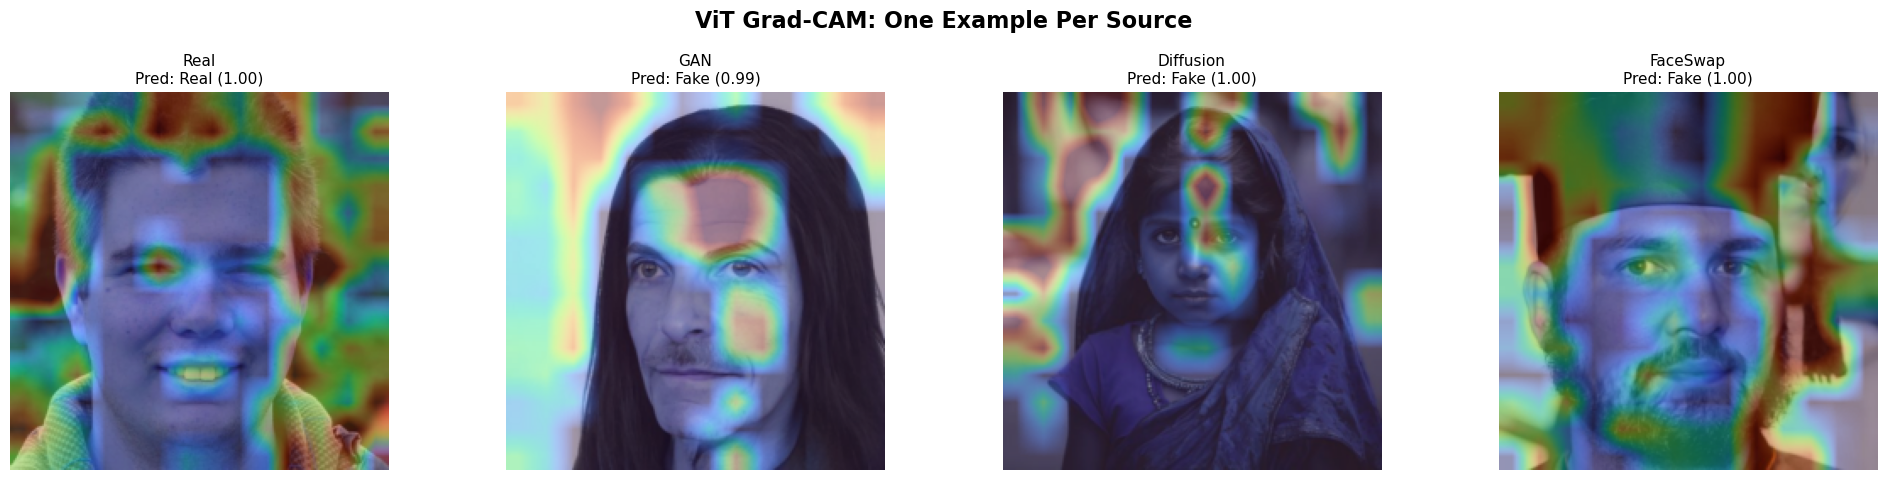

In [18]:
# ============================================================================
# Generate 1x4 Grad-CAM Visualization (Real, GAN, Diffusion, FaceSwap)
# ============================================================================
print("\n" + "="*70)
print("GENERATING 1x4 GRAD-CAM VISUALIZATION")
print("="*70)

single_sources = [
    ("Real", real_paths),
    ("GAN", gan_paths),
    ("Diffusion", diff_paths),
    ("FaceSwap", faceswap_paths),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, (source_name, paths) in zip(axes, single_sources):
    if not paths:
        ax.set_title(f"{source_name}\n(No images)", fontsize=11)
        ax.axis("off")
        continue

    img_path = random.choice(paths)
    img = Image.open(img_path).convert("RGB")
    img_tensor = get_data_transforms(image_size=IMAGE_SIZE)["val"](img).unsqueeze(0).to(device)

    with torch.no_grad():
        vit_model.eval()
        outputs = vit_model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred_class = outputs.argmax(dim=1).item()
        pred_conf = probs[0, pred_class].item()

    cam = grad_cam.generate_cam(img_tensor, target_class=pred_class, patch_size=16)

    img_vis = inv_normalize(img_tensor[0].cpu()).detach().numpy().transpose(1, 2, 0)
    img_vis = np.clip(img_vis * 255, 0, 255).astype(np.uint8)
    overlay = AttentionVisualization.create_heatmap(img_vis, cam)

    ax.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    pred_label = "Real" if pred_class == 0 else "Fake"
    ax.set_title(f"{source_name}\nPred: {pred_label} ({pred_conf:.2f})", fontsize=11)
    ax.axis("off")

plt.suptitle("ViT Grad-CAM: One Example Per Source", fontsize=16, fontweight="bold")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## 2.4 Average Grad-CAM and Overlay

In [19]:
# ============================================================================
# Pre-compute Real Image Attention Maps (Reference for All Comparisons)
# ============================================================================
print("\n" + "="*70)
print("PRE-COMPUTING REFERENCE REAL IMAGE ATTENTION MAPS")
print("="*70)
print("Computing Grad-CAM attention maps for real images (used as reference for all comparisons)...")

# Sample real images
num_samples = min(MAX_SAMPLES_FOR_ANALYSIS, len(real_paths))
real_sample = random.sample(real_paths, num_samples)

real_cams = []
real_imgs = []

# Compute attention maps
for i, img_path in enumerate(real_sample):
    if (i + 1) % 500 == 0:
        print(f"  Processing {i+1}/{len(real_sample)} real images...")
    
    try:
        img = Image.open(img_path).convert("RGB")
        img_tensor = get_data_transforms(image_size=IMAGE_SIZE)['val'](img).unsqueeze(0).to(device)
        
        with torch.no_grad():
            vit_model.eval()
            outputs = vit_model(img_tensor)
            pred_class = outputs.argmax(dim=1).item()
        
        cam = grad_cam.generate_cam(img_tensor, target_class=pred_class, patch_size=16)
        real_cams.append(cam)
        
        # Store normalized image for averaging
        img_vis = inv_normalize(img_tensor[0].cpu()).detach().numpy().transpose(1, 2, 0)
        img_vis = np.clip(img_vis, 0, 1)
        real_imgs.append(img_vis)
    except Exception as e:
        logger.warning(f"Error processing {img_path}: {e}")
        continue

# Compute average attention map for real faces
if real_cams:
    avg_real_cam = np.mean(real_cams, axis=0)
    avg_real_img = np.mean(real_imgs, axis=0)
    real_overlay = AttentionVisualization.create_heatmap((avg_real_img * 255).astype(np.uint8), avg_real_cam)
    
    stats = compute_and_print_attention_statistics(real_cams, "Real Faces")
    print("✓ Real image attention maps computed and stored\n")
else:
    print("✗ Failed to compute real image attention maps")
    real_cams = []
    avg_real_cam = None
    avg_real_img = None
    real_overlay = None


PRE-COMPUTING REFERENCE REAL IMAGE ATTENTION MAPS
Computing Grad-CAM attention maps for real images (used as reference for all comparisons)...
  Processing 500/1000 real images...
  Processing 1000/1000 real images...

Real Faces Attention Statistics:
  Mean: 0.1619 | Std: 0.0258
  Min:  0.1023 | Max: 0.2796
✓ Real image attention maps computed and stored




ANALYZING REAL vs GAN

Processing 1000 GAN images...
  500/1000
  1000/1000

Statistics:

Real vs GAN Attention Comparison:
  Real                 - Mean: 0.1619 | Std: 0.0258
  GAN                  - Mean: 0.1560 | Std: 0.0331
  Mean Difference: -0.0059


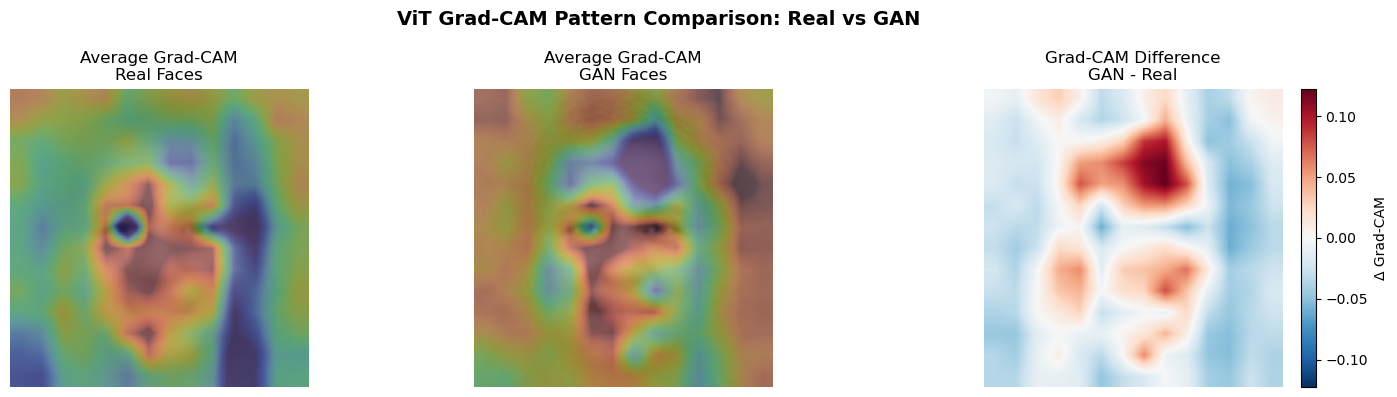

Saved to ./vit_model_outputs/gradcam_comparison_real_vs_gan.png


ANALYZING REAL vs DIFFUSION

Processing 1000 Diffusion images...
  500/1000
  1000/1000

Statistics:

Real vs Diffusion Attention Comparison:
  Real                 - Mean: 0.1619 | Std: 0.0258
  Diffusion            - Mean: 0.1687 | Std: 0.0272
  Mean Difference: +0.0068


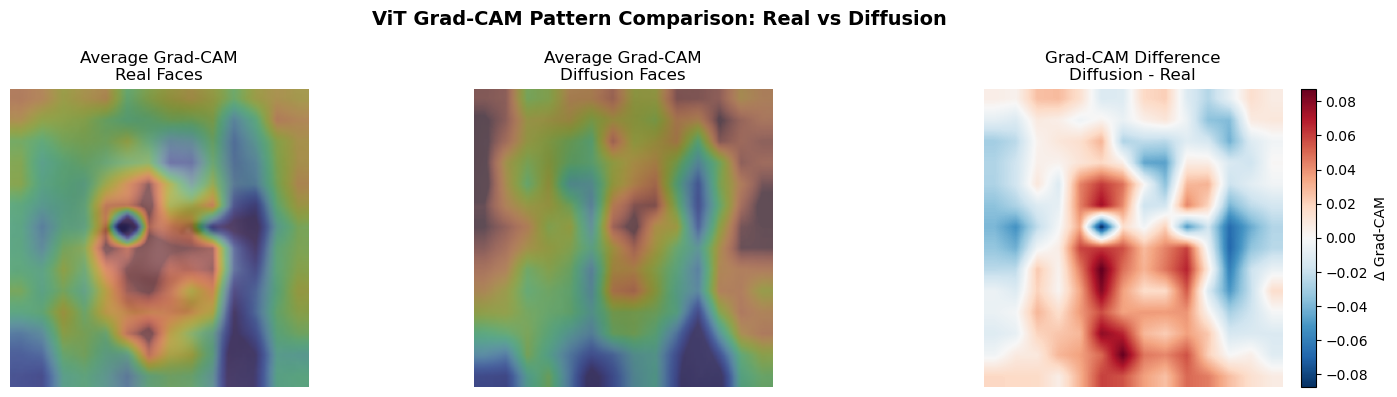

Saved to ./vit_model_outputs/gradcam_comparison_real_vs_diffusion.png


ANALYZING REAL vs FACESWAP

Processing 1000 FaceSwap images...
  500/1000
  1000/1000

Statistics:

Real vs FaceSwap Attention Comparison:
  Real                 - Mean: 0.1619 | Std: 0.0258
  FaceSwap             - Mean: 0.1584 | Std: 0.0260
  Mean Difference: -0.0035


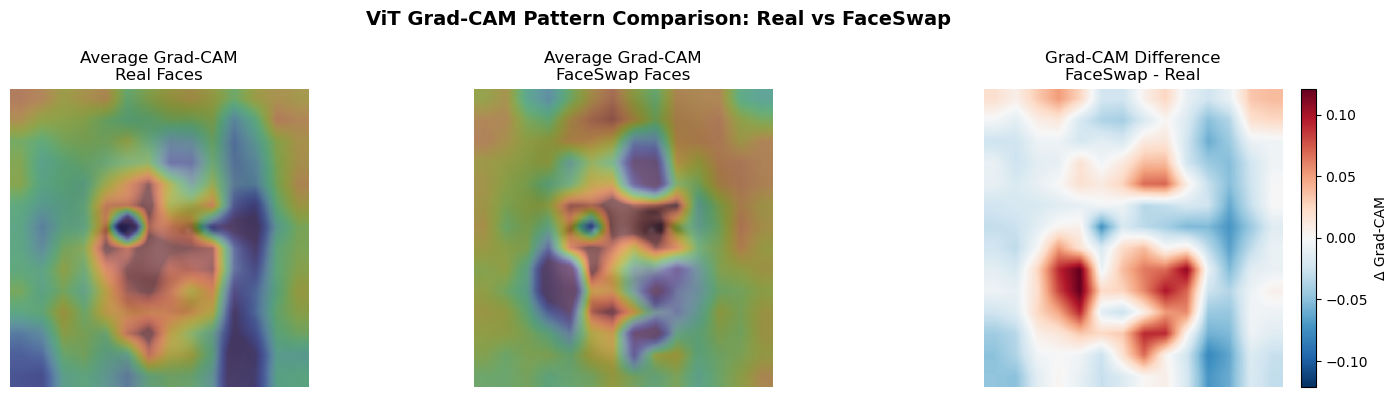

Saved to ./vit_model_outputs/gradcam_comparison_real_vs_faceswap.png



In [20]:
# ============================================================================
# Analyze Real vs GAN
# ============================================================================
gan_cam, gan_overlay, gan_stats = analyze_gradcam_by_source(
    gan_paths, "GAN", avg_real_cam, real_overlay,
    grad_cam, vit_model, inv_normalize, device, IMAGE_SIZE, MAX_SAMPLES_FOR_ANALYSIS
)

# ============================================================================
# Analyze Real vs Diffusion
# ============================================================================
diff_cam, diff_overlay, diff_stats = analyze_gradcam_by_source(
    diff_paths, "Diffusion", avg_real_cam, real_overlay,
    grad_cam, vit_model, inv_normalize, device, IMAGE_SIZE, MAX_SAMPLES_FOR_ANALYSIS
)

# ============================================================================
# Analyze Real vs FaceSwap
# ============================================================================
faceswap_cam, faceswap_overlay, faceswap_stats = analyze_gradcam_by_source(
    faceswap_paths, "FaceSwap", avg_real_cam, real_overlay,
    grad_cam, vit_model, inv_normalize, device, IMAGE_SIZE, MAX_SAMPLES_FOR_ANALYSIS
)

## 2.5 Attention Rollout Analysis

In [21]:
# Get 1/10 of test samples (RANDOM)
test_dataset = test_loader.dataset
subset_size = len(test_dataset) // 10
random_indices = torch.randperm(len(test_dataset))[:subset_size]

small_subset = Subset(test_dataset, random_indices)

test_loader_small = DataLoader(
    small_subset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,  # Keep in original order for reproducibility
    num_workers=NUM_WORKERS
)

print(f"Original: {len(test_loader.dataset)} samples")
print(f"Small: {len(test_loader_small.dataset)} samples")

Original: 24190 samples
Small: 2419 samples


In [22]:
print("\n" + "="*60)
print("Analyzing Attention Rollout by Class")
print("="*60)

# Import the Attention Rollout class from existing module

# Initialize Attention Rollout
print("\nInitializing Attention Rollout...")
rollout = ViTAttentionRollout(vit_model, device, discard_ratio=0.9)
print("✓ Attention Rollout initialized with discard_ratio=0.9")

# Compute attention rollout maps for all test samples
print("\nComputing Attention Rollout maps for test set...")
print("This propagates attention weights across all transformer layers")

real_rollouts = []
fake_rollouts = []

with torch.no_grad():
    batch_count = 0
    for batch_images, batch_labels in test_loader_small:
        batch_images = batch_images.to(device)
        
        # Generate rollout maps for this batch
        batch_rollouts = rollout.generate_batch_cams(batch_images, patch_size=16)
        
        # Separate by class
        for i, (rollout_map, label) in enumerate(zip(batch_rollouts, batch_labels.cpu().numpy())):
            if label == 0:
                real_rollouts.append(rollout_map)
            else:
                fake_rollouts.append(rollout_map)
        
        batch_count += 1
        if batch_count % 10 == 0:
            print(f"  Processed {batch_count}/{len(test_loader_small)} batches")
       

# Clean up hooks to free memory
rollout.remove_hooks()

INFO:vit_helpers.vit_attention_rollout:Registered hooks on 12 attention layers



Analyzing Attention Rollout by Class

Initializing Attention Rollout...
✓ Attention Rollout initialized with discard_ratio=0.9

Computing Attention Rollout maps for test set...
This propagates attention weights across all transformer layers
  Processed 10/19 batches


INFO:vit_helpers.vit_attention_rollout:Removed all hooks


In [23]:
# Pre-compute real attention rollout (reuse across all comparisons)
print("\n" + "="*60)
print("Pre-computing Real Image Attention Rollout (Used for All Comparisons)")
print("="*60)

num_samples = min(500, len(real_paths))  # Adjust as needed
real_sample = random.sample(real_paths, num_samples)

print(f"\nProcessing {len(real_sample)} real images...")
real_rollouts_source, real_imgs_source = compute_attention_rollout_for_paths(
    real_sample, rollout, device, vit_model, inv_normalize, IMAGE_SIZE
)

# Average real
avg_real_rollout_source = np.mean(real_rollouts_source, axis=0)
avg_real_img_source = np.mean(real_imgs_source, axis=0)

# Normalize, resize, blur
cls_attention_real = (avg_real_rollout_source - avg_real_rollout_source.min()) / (avg_real_rollout_source.max() - avg_real_rollout_source.min() + 1e-10)
cls_attention_real_resized = Image.fromarray((cls_attention_real * 255).astype(np.uint8)).resize((IMAGE_SIZE, IMAGE_SIZE), resample=Image.BICUBIC)
cls_attention_real_resized = cls_attention_real_resized.filter(ImageFilter.GaussianBlur(radius=2))
avg_real_rollout_normalized = np.array(cls_attention_real_resized) / 255.0

# Create overlay
real_rollout_overlay = AttentionVisualization.create_heatmap((avg_real_img_source * 255).astype(np.uint8), avg_real_rollout_normalized)

print(f"\nReal faces - Mean rollout: {avg_real_rollout_normalized.mean():.4f} | Std: {avg_real_rollout_normalized.std():.4f}")
print("✓ Real attention rollout computed and stored\n")

INFO:vit_helpers.vit_attention_rollout:Removed all hooks
INFO:vit_helpers.vit_attention_rollout:Registered hooks on 12 attention layers
INFO:vit_helpers.vit_attention_rollout:Re-registered all hooks



Pre-computing Real Image Attention Rollout (Used for All Comparisons)

Processing 500 real images...

Real faces - Mean rollout: 0.2977 | Std: 0.1562
✓ Real attention rollout computed and stored



### 2.5.1 Real vs GAN

INFO:vit_helpers.vit_attention_rollout:Removed all hooks
INFO:vit_helpers.vit_attention_rollout:Registered hooks on 12 attention layers
INFO:vit_helpers.vit_attention_rollout:Re-registered all hooks



Processing 500 GAN images...

Real faces       - Mean rollout: 0.2977 | Std: 0.1562
GAN faces  - Mean rollout: 0.2906 | Std: 0.1780


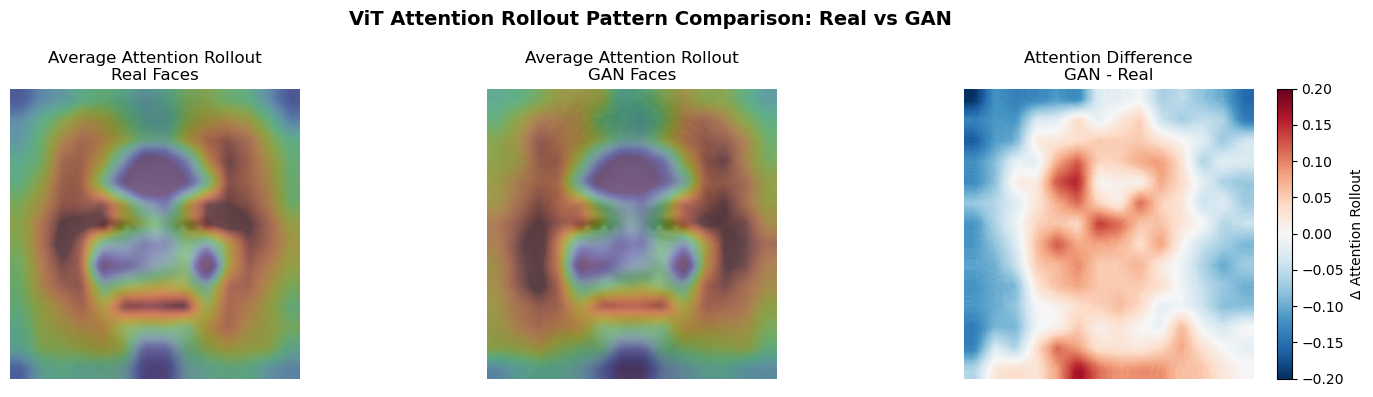


✓ Saved to ./vit_model_outputs/vit_rollout_real_vs_gan.png


In [24]:
# gan 
compute_and_visualize_rollout_comparison(
    gan_paths,
    rollout,
    device,
    vit_model,
    inv_normalize,
    avg_real_rollout_normalized,
    real_rollout_overlay,
    method_name="GAN",
    num_samples=500,
    IMAGE_SIZE=IMAGE_SIZE,
    save_path="./vit_model_outputs/",
)

### 2.5.2 Real vs Diffusion

INFO:vit_helpers.vit_attention_rollout:Removed all hooks
INFO:vit_helpers.vit_attention_rollout:Registered hooks on 12 attention layers
INFO:vit_helpers.vit_attention_rollout:Re-registered all hooks



Processing 500 Diffusion images...

Real faces       - Mean rollout: 0.2977 | Std: 0.1562
Diffusion faces  - Mean rollout: 0.3574 | Std: 0.2064


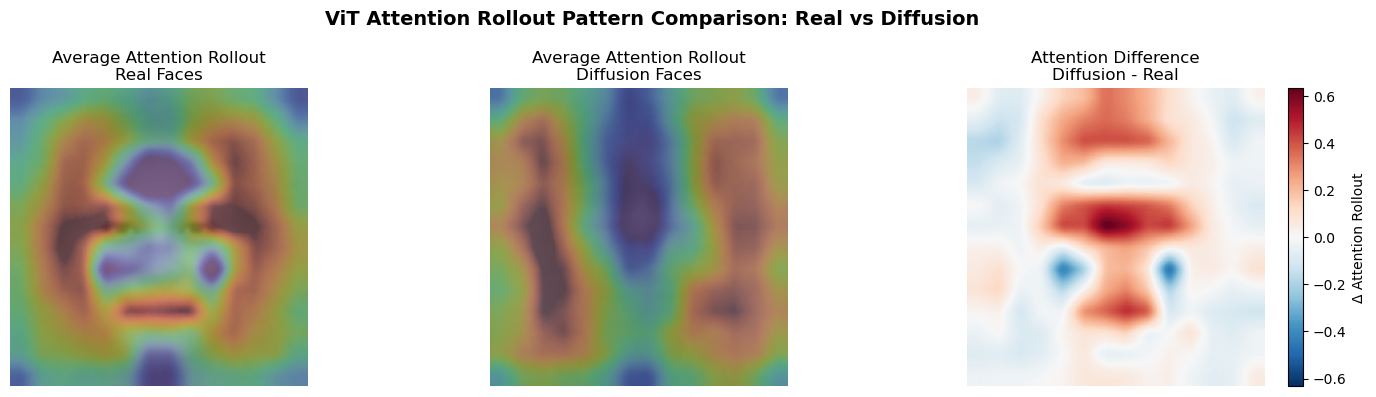


✓ Saved to ./vit_model_outputs/vit_rollout_real_vs_diffusion.png


In [25]:
# diffusion 
compute_and_visualize_rollout_comparison(
    diff_paths,
    rollout,
    device,
    vit_model,
    inv_normalize,
    avg_real_rollout_normalized,
    real_rollout_overlay,
    method_name="Diffusion",
    num_samples=500,
    IMAGE_SIZE=IMAGE_SIZE,
    save_path="./vit_model_outputs/",
)

### 2.5.3 Real vs Face Swaps

INFO:vit_helpers.vit_attention_rollout:Removed all hooks
INFO:vit_helpers.vit_attention_rollout:Registered hooks on 12 attention layers
INFO:vit_helpers.vit_attention_rollout:Re-registered all hooks



Processing 500 FaceSwap images...

Real faces       - Mean rollout: 0.2977 | Std: 0.1562
FaceSwap faces  - Mean rollout: 0.2069 | Std: 0.2184


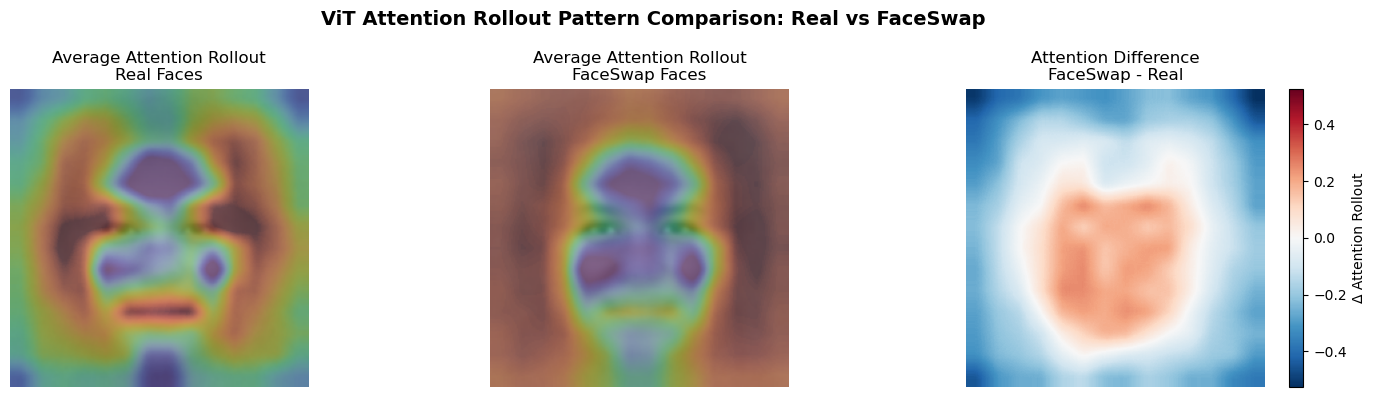


✓ Saved to ./vit_model_outputs/vit_rollout_real_vs_faceswap.png


In [26]:
# faceswap 
compute_and_visualize_rollout_comparison(
    faceswap_paths,
    rollout,
    device,
    vit_model,
    inv_normalize,
    avg_real_rollout_normalized,
    real_rollout_overlay,
    method_name="FaceSwap",
    num_samples=500,
    IMAGE_SIZE=IMAGE_SIZE,
    save_path="./vit_model_outputs/",
)